In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv("Superstore.csv")

In [2]:
print(df.info())
df =df.drop(columns=["Row ID","Customer ID","Customer Name","Product ID","Product Name","Postal Code","Order ID"]
           )
df["Order Date"] = pd.to_datetime(df["Order Date"],dayfirst= True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst= True)
df["Ship Mode"].unique()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

C:\Users\Ayush\AppData\Local\Temp\ipykernel_25824\3856742221.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Order Date"] = pd.to_datetime(df["Order Date"],dayfirst= True)
C:\Users\Ayush\AppData\Local\Temp\ipykernel_25824\3856742221.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst= True)


array(['Second Class', 'Standard Class', 'First Class', 'Same Day'],
      dtype=object)

In [3]:
# Creating time based 
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Day"] = df["Order Date"].dt.day
df["DayofWeek"] = df["Order Date"].dt.dayofweek

In [4]:

df["profit_margin"] = df["Profit"] / (df["Sales"] + 1)

df["discount_quantity"] = df["Discount"] * df["Quantity"]

df = df.sort_values("Order Date")
df = df.dropna().reset_index(drop=True)
df = df.drop(columns=["Country","City","State","Year","Ship Date","Ship Mode", "Segment"])


In [5]:
df.isnull().sum()

df.head(20)

,Order Date,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Month,Day,DayofWeek,profit_margin,discount_quantity
0,2014-01-02,Central,Technology,Accessories,468.900,6,0.0,206.3160,1,2,3,0.439064,0.0
1,2014-01-03,Central,Furniture,Chairs,634.116,6,0.3,-172.1172,1,3,4,-0.271001,1.8
2,2014-01-03,Central,Furniture,Chairs,362.250,6,0.3,0.0000,1,3,4,0.000000,1.8
3,2014-01-03,Central,Furniture,Furnishings,63.552,6,0.6,-34.9536,1,3,4,-0.541480,3.6
4,2014-01-03,East,Technology,Phones,5.940,3,0.0,1.6038,1,3,4,0.231095,0.0
5,2014-01-03,Central,Furniture,Tables,376.509,3,0.3,-43.0296,1,3,4,-0.113983,0.9
6,2014-01-03,Central,Office Supplies,Storage,129.552,3,0.2,-22.6716,1,3,4,-0.173660,0.6
7,2014-01-03,Central,Office Supplies,Storage,137.352,3,0.2,8.5845,1,3,4,0.062048,0.6
8,2014-01-03,West,Furniture,Chairs,457.568,2,0.2,51.4764,1,3,4,0.112255,0.4
9,2014-01-03,Central,Office Supplies,Fasteners,18.840,5,0.2,-3.5325,1,3,4,-0.178049,1.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Order Date         9994 non-null   datetime64[ns]
 1   Region             9994 non-null   object        
 2   Category           9994 non-null   object        
 3   Sub-Category       9994 non-null   object        
 4   Sales              9994 non-null   float64       
 5   Quantity           9994 non-null   int64         
 6   Discount           9994 non-null   float64       
 7   Profit             9994 non-null   float64       
 8   Month              9994 non-null   int32         
 9   Day                9994 non-null   int32         
 10  DayofWeek          9994 non-null   int32         
 11  profit_margin      9994 non-null   float64       
 12  discount_quantity  9994 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int32(3), int64(1), object(3)

# EDA

<Axes: ylabel='Sales'>

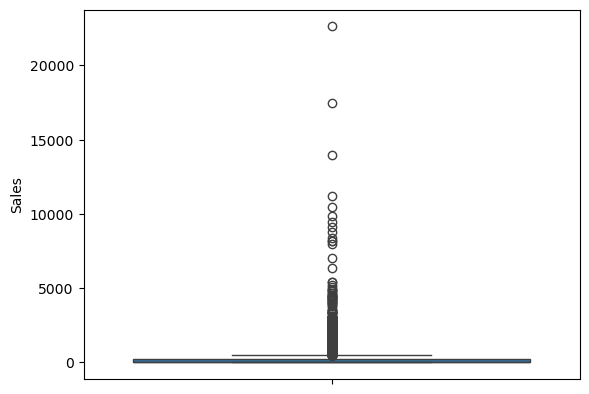

In [7]:
sns.boxplot(
    y = df["Sales"]
)

<Axes: xlabel='Category', ylabel='Sales'>

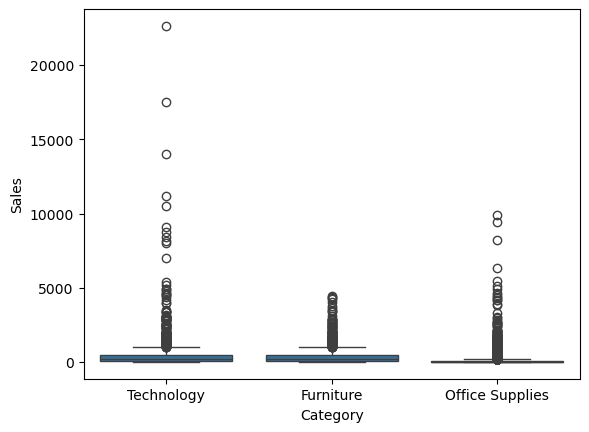

In [8]:
sns.boxplot(
    data = df,
    x= "Category",
    y = "Sales"
)
# Mostly sales are from Technology category thus have high demand of tech products

<Axes: xlabel='Sub-Category', ylabel='Sales'>

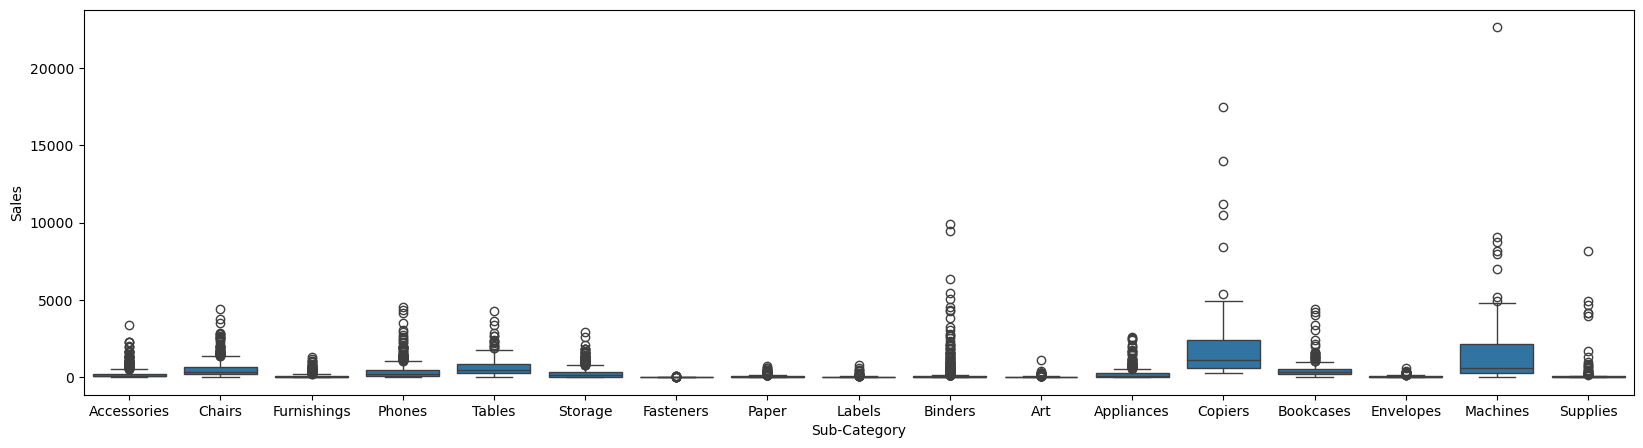

In [9]:
plt.figure(figsize=(20,5))
sns.boxplot(
    data = df,
    x = "Sub-Category",
    y = "Sales",

)
# copier has highest demand while machines also have demand with sudden spike

(0.0, 5000.0)

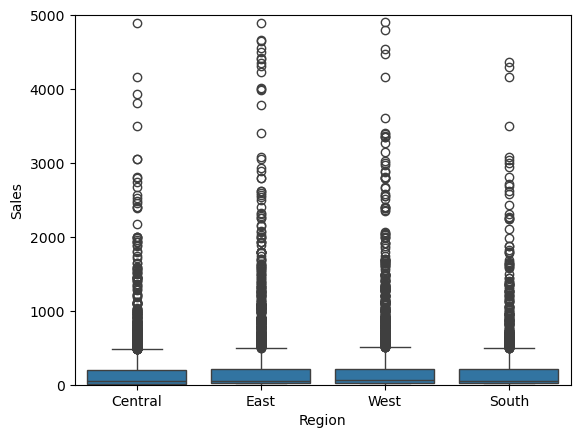

In [10]:
sns.boxplot(
    data = df,
    x= "Region",
    y = "Sales"
)
plt.ylim(0,5000)
# Sales across regions are generally consistent, but overall revenue is heavily influenced by occasional high-value transactions, especially in the South and West regions.

Text(0.5, 1.0, 'Sales Distribution')

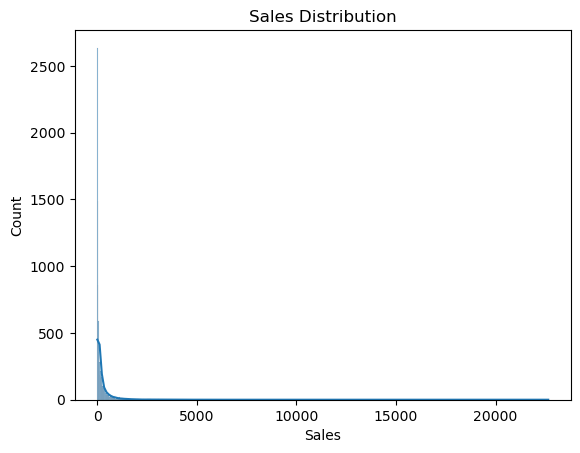

In [11]:
sns.histplot(df["Sales"], kde=True)
plt.title("Sales Distribution")

<Axes: xlabel='Discount', ylabel='Sales'>

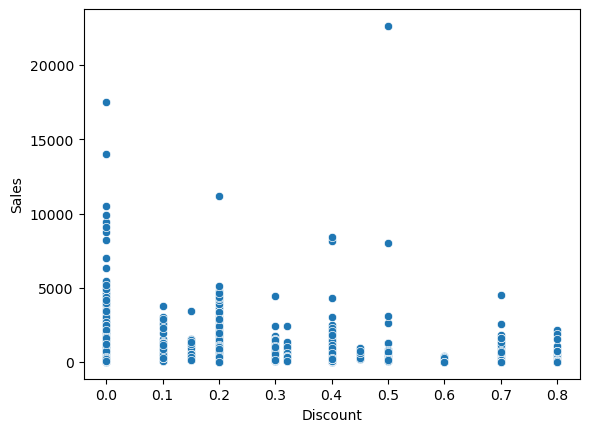

In [12]:
sns.scatterplot(
    data = df,
    x= "Discount",
    y= "Sales"
)
# Sales are not strongly driven by discounts, and high discounts do not consistently result in higher revenue, indicating the need for optimized discount strategies.

<Axes: xlabel='Quantity', ylabel='Sales'>

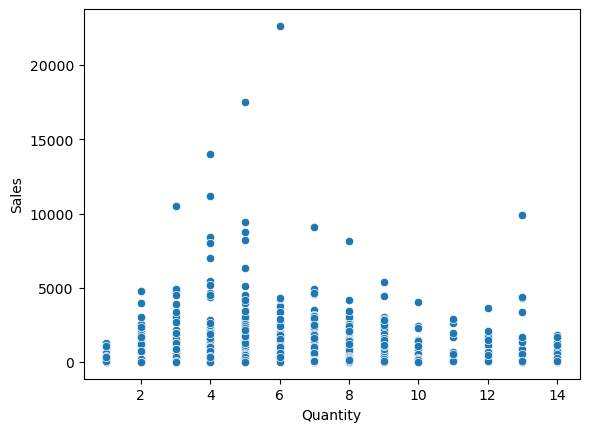

In [13]:
sns.scatterplot(
    data = df,
    x= "Quantity",
    y= "Sales"
)
# Quantity has a limited impact on sales, as high revenue is often generated from moderate-sized orders rather than very large quantities.

<Axes: xlabel='Profit', ylabel='Sales'>

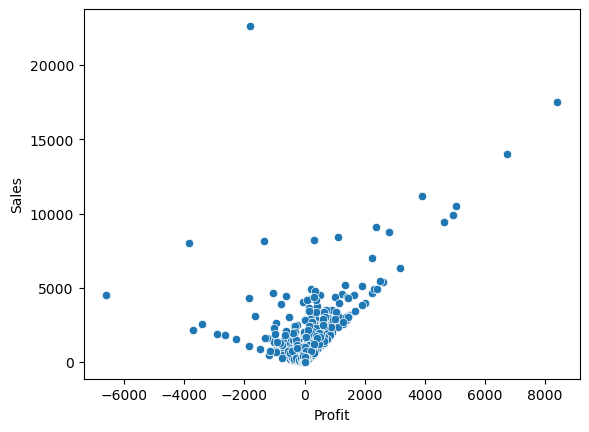

In [14]:
sns.scatterplot(
    data = df,
    x= "Profit",
    y= "Sales"
)
# Although sales and profit are positively correlated, a significant number of transactions generate low or negative profit, indicating inefficiencies in pricing or discount strategies.

<Axes: xlabel='Month', ylabel='Sales'>

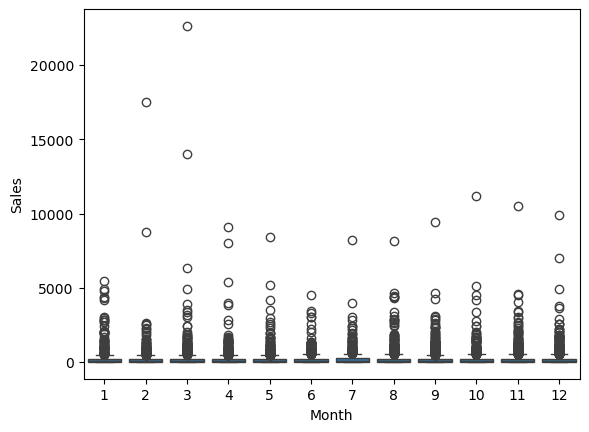

In [15]:
sns.boxplot(
    data = df,
    x = "Month",
    y = "Sales"
)
# Due to festive season (march(highest), sept-december ) have high sales compared to other

<Axes: xlabel='DayofWeek', ylabel='Sales'>

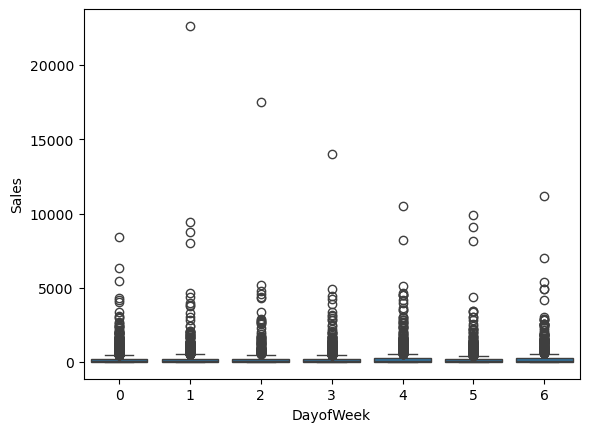

In [16]:
sns.boxplot(
    data = df,
    x = "DayofWeek",
    y = "Sales"
)
# Sales are relatively stable across weekdays, with a slight increase during weekends, indicating limited but noticeable weekly seasonality

                      Sales  Quantity  Discount    Profit     Month       Day  \
Sales              1.000000  0.200795 -0.028190  0.479064 -0.011178  0.007915   
Quantity           0.200795  1.000000  0.008623  0.066253  0.008582  0.018464   
Discount          -0.028190  0.008623  1.000000 -0.219487 -0.001939 -0.005543   
Profit             0.479064  0.066253 -0.219487  1.000000 -0.014366  0.002687   
Month             -0.011178  0.008582 -0.001939 -0.014366  1.000000  0.155636   
Day                0.007915  0.018464 -0.005543  0.002687  0.155636  1.000000   
DayofWeek         -0.006294  0.001871  0.010032 -0.004465 -0.000179  0.040039   
profit_margin      0.001846 -0.004961 -0.859389  0.243703  0.002305  0.008719   
discount_quantity  0.036533  0.355408  0.814126 -0.210114 -0.003335 -0.005970   

                   DayofWeek  profit_margin  discount_quantity  
Sales              -0.006294       0.001846           0.036533  
Quantity            0.001871      -0.004961           0.355

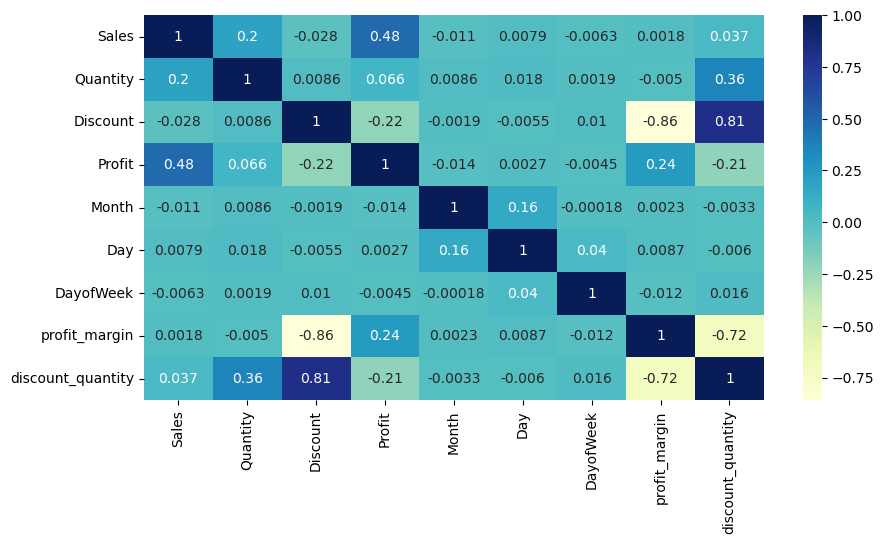

In [17]:
co_mtx = df.corr(numeric_only=True)
plt.figure(figsize=(10,5))
# Print correlation matrix
print(co_mtx)

# Plot correlation heatmap
sns.heatmap(co_mtx, cmap="YlGnBu", annot=True)

# Display heatmap
plt.show()

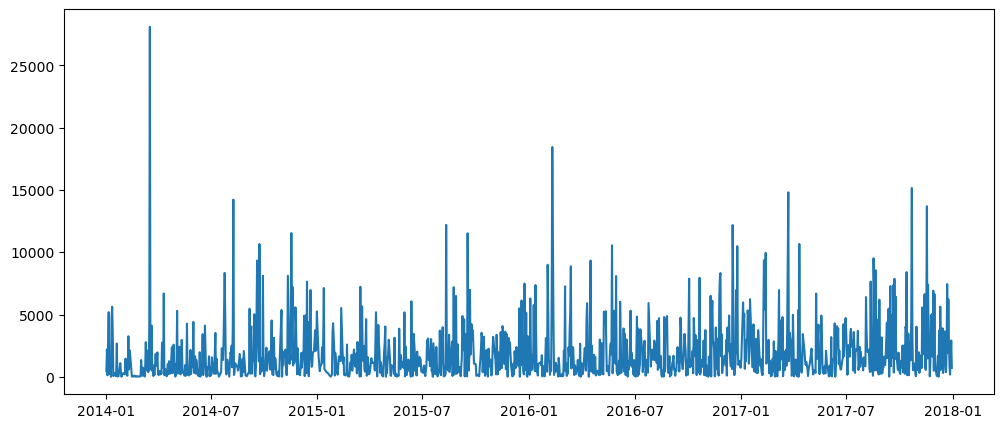

In [18]:
daily = df.groupby("Order Date")["Sales"].sum().reset_index()

plt.figure(figsize=(12,5))
plt.plot(daily["Order Date"], daily["Sales"])

In [19]:
df = pd.get_dummies(df, columns=["Region","Category","Sub-Category",], drop_first = True, dtype= int)

# Train the Model

In [20]:
#  Train test split
# As we have time series data thus we can't do random split because based on past data we have to predict future insights
df = df.sort_values("Order Date")
from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42)
split_index = int(len(df)*0.8)

train = df.iloc[:split_index]  # first 80% data
test = df.iloc[split_index:]   # last 20% data

X_train = train.drop(columns = ["Sales", "Order Date","Day","profit_margin"])
y_train = train["Sales"]

X_test = test.drop(columns = ["Sales", "Order Date","Day","profit_margin"])
y_test = test["Sales"]
X_test.tail()

,Quantity,Discount,Profit,Month,DayofWeek,discount_quantity,Region_East,Region_South,Region_West,Category_Office Supplies,...,Sub-Category_Envelopes,Sub-Category_Fasteners,Sub-Category_Furnishings,Sub-Category_Labels,Sub-Category_Machines,Sub-Category_Paper,Sub-Category_Phones,Sub-Category_Storage,Sub-Category_Supplies,Sub-Category_Tables
9992,4,0.2,12.1176,12,5,0.8,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9988,3,0.2,19.7910,12,5,0.6,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
9987,2,0.0,56.5110,12,5,0.0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
9989,7,0.0,2.7279,12,5,0.0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
9993,2,0.2,4.5188,12,5,0.4,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0


In [21]:
# Standard Scaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled

array([[ 0.99083421, -0.75600685,  0.74674258, ..., -0.29947025,
        -0.13921329, -0.17854746],
       [-0.35762009,  0.20834606, -0.09675119, ..., -0.29947025,
        -0.13921329, -0.17854746],
       [-0.80710485,  0.20834606,  0.09578664, ..., -0.29947025,
        -0.13921329, -0.17854746],
       ...,
       [-0.80710485,  0.20834606, -0.09388065, ..., -0.29947025,
        -0.13921329, -0.17854746],
       [ 0.09186468,  0.20834606, -0.33850854, ...,  3.33922984,
        -0.13921329, -0.17854746],
       [-1.25658962, -0.75600685, -0.06960806, ..., -0.29947025,
        -0.13921329, -0.17854746]])

# Training of Models

In [22]:
def train_model(model, X_train_scaled, y_train, X_test_scaled, y_test):
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    preds = model.predict(X_test)
    
    # Evaluation
    from sklearn.metrics import mean_absolute_error, mean_squared_error , r2_score
    import numpy as np
    
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print(f"Model: {model.__class__.__name__}")
    print(f"MAE: {mae}")
    print(f"RMSE: {rmse}")
    print(f"r2_score: {r2}")
    return preds

In [23]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_preds = train_model(lr_model, X_train_scaled, y_train, X_test_scaled, y_test)

Model: LinearRegression
MAE: 182.4161474314079
RMSE: 407.43146190986084
r2_score: 0.4642740825507562


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42)
rf_preds = train_model(rf_model,X_train_scaled, y_train, X_test_scaled,  y_test)

In [ ]:
print(lr_model.score(X_train, y_train))
print(rf_model.score(X_test, y_test))